In [5]:
# ============================================================
# 1. LIBRARIES
# ============================================================
import os
import csv
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay,
                             f1_score)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")

PyTorch 2.4.1+cu124 | CUDA: True


In [6]:
# ============================================================
# 2. CONFIGURATION
# ============================================================
IMG_SIZE   = 224
SEG_SIZE   = 256
BATCH_SIZE = 32
NUM_EPOCHS = 20
LR         = 1e-4
SEED       = 42

CLASS_NAMES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
NUM_CLASSES = len(CLASS_NAMES)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Classes:", CLASS_NAMES)

Device: cuda
Classes: ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']


In [7]:
# ============================================================
# 3. PATHS AND LABELS
# ============================================================
IMG_DIR   = "/workspace/datasets/ISIC2019/images/ISIC_2019_Training_Input"
CSV_PATH  = "/workspace/datasets/ISIC2019/labels.csv"
UNET_PATH = "/workspace/unet_best.pth"
MASK_DIR  = "/workspace/datasets/ISIC2019/masks"

os.makedirs(MASK_DIR, exist_ok=True)

# Load CSV
df = pd.read_csv(CSV_PATH)
print("Columnas:", df.columns.tolist())
print(f"Total images before filtering: {len(df)}")

# Filter UNK (images with no defined class)
df = df[df['UNK'] == 0.0].reset_index(drop=True)
print(f"Total after filtering UNK: {len(df)}")

# Convert one-hot to numeric label
df['label']    = df[CLASS_NAMES].values.argmax(axis=1)
df['filename'] = df['image'].apply(lambda x: x + '.jpg')

# Filter only those that exist on disk.
df = df[df['filename'].apply(
    lambda x: os.path.exists(os.path.join(IMG_DIR, x))
)].reset_index(drop=True)

print(f"Images found on disk: {len(df)}")
print("\nClass Schedule:")
for i, cls in enumerate(CLASS_NAMES):
    n = (df['label'] == i).sum()
    print(f"  {cls}: {n} ({100*n/len(df):.1f}%)")

Columnas: ['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']
Total images before filtering: 25331
Total after filtering UNK: 25331
Images found on disk: 25331

Class Schedule:
  MEL: 4522 (17.9%)
  NV: 12875 (50.8%)
  BCC: 3323 (13.1%)
  AK: 867 (3.4%)
  BKL: 2624 (10.4%)
  DF: 239 (0.9%)
  VASC: 253 (1.0%)
  SCC: 628 (2.5%)


In [8]:
# ============================================================
# 4. U-NET DEFINITION
# ============================================================
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1, self.p1 = DoubleConv(3,   64),  nn.MaxPool2d(2)
        self.d2, self.p2 = DoubleConv(64,  128), nn.MaxPool2d(2)
        self.d3, self.p3 = DoubleConv(128, 256), nn.MaxPool2d(2)
        self.d4, self.p4 = DoubleConv(256, 512), nn.MaxPool2d(2)
        self.bn          = DoubleConv(512, 1024)
        self.u4 = nn.ConvTranspose2d(1024, 512, 2, 2); self.c4 = DoubleConv(1024, 512)
        self.u3 = nn.ConvTranspose2d(512,  256, 2, 2); self.c3 = DoubleConv(512,  256)
        self.u2 = nn.ConvTranspose2d(256,  128, 2, 2); self.c2 = DoubleConv(256,  128)
        self.u1 = nn.ConvTranspose2d(128,   64, 2, 2); self.c1 = DoubleConv(128,   64)
        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        x1 = self.d1(x); p1 = self.p1(x1)
        x2 = self.d2(p1); p2 = self.p2(x2)
        x3 = self.d3(p2); p3 = self.p3(x3)
        x4 = self.d4(p3); p4 = self.p4(x4)
        b  = self.bn(p4)
        x  = self.c4(torch.cat([self.u4(b),  x4], dim=1))
        x  = self.c3(torch.cat([self.u3(x),  x3], dim=1))
        x  = self.c2(torch.cat([self.u2(x),  x2], dim=1))
        x  = self.c1(torch.cat([self.u1(x),  x1], dim=1))
        return self.out(x)

unet = UNet().to(device)
unet.load_state_dict(torch.load(UNET_PATH, map_location=device, weights_only=True))
unet.eval()
print("U-Net loaded successfully")

U-Net loaded successfully


In [9]:
# ============================================================
# 5. GENERATE MASKS FOR ALL ISIC 2019 IMAGES
# ============================================================
seg_mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(device)
seg_std  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(device)

already_done = set(os.listdir(MASK_DIR))
to_process   = [f for f in df['filename'].tolist()
                if f.replace('.jpg', '_mask.png') not in already_done]

print(f"Masks already generated : {len(already_done)}")
print(f"Images to process   : {len(to_process)}")

MASK_BATCH = 16
errors = 0

with torch.no_grad():
    for start in range(0, len(to_process), MASK_BATCH):
        batch_files = to_process[start:start + MASK_BATCH]
        imgs, valid_files = [], []

        for fname in batch_files:
            try:
                img = Image.open(os.path.join(IMG_DIR, fname)).convert("RGB")
                img = img.resize((SEG_SIZE, SEG_SIZE), Image.BILINEAR)
                img_t = torch.tensor(np.array(img)).permute(2,0,1).float() / 255.0
                imgs.append(img_t)
                valid_files.append(fname)
            except Exception:
                errors += 1

        if not imgs:
            continue

        batch_t = torch.stack(imgs).to(device)
        batch_t = (batch_t - seg_mean) / seg_std

        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = unet(batch_t)

        masks = (torch.sigmoid(logits) > 0.5).squeeze(1).cpu().numpy()

        for fname, mask in zip(valid_files, masks):
            mask_img  = Image.fromarray((mask * 255).astype(np.uint8))
            mask_name = fname.replace('.jpg', '_mask.png')
            mask_img.save(os.path.join(MASK_DIR, mask_name))

        if (start // MASK_BATCH) % 100 == 0:
            print(f"  Processed {start + len(batch_files)}/{len(to_process)}...")

print(f"\n Generated masks. Errors: {errors}")
print(f"   Total on disk: {len(os.listdir(MASK_DIR))}")

Masks already generated : 0
Images to process   : 25331
  Processed 16/25331...
  Processed 1616/25331...
  Processed 3216/25331...
  Processed 4816/25331...
  Processed 6416/25331...
  Processed 8016/25331...
  Processed 9616/25331...
  Processed 11216/25331...
  Processed 12816/25331...
  Processed 14416/25331...
  Processed 16016/25331...
  Processed 17616/25331...
  Processed 19216/25331...
  Processed 20816/25331...
  Processed 22416/25331...
  Processed 24016/25331...

 Generated masks. Errors: 0
   Total on disk: 25331


In [10]:
# ============================================================
# 6. DATASETS — A (original) y B (masked)
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.1),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class ISIC2019Original(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(os.path.join(self.img_dir,
                           row['filename'])).convert("RGB")
        label = int(row['label'])
        if self.transform:
            img = self.transform(img)
        return img, label, row['filename']

class ISIC2019Masked(Dataset):
    def __init__(self, dataframe, img_dir, mask_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row       = self.df.iloc[idx]
        img       = Image.open(os.path.join(self.img_dir,
                               row['filename'])).convert("RGB")
        mask_name = row['filename'].replace('.jpg', '_mask.png')
        mask_path = os.path.join(self.mask_dir, mask_name)

        if os.path.exists(mask_path):
            mask    = Image.open(mask_path).convert("L")
            mask    = mask.resize(img.size, Image.NEAREST)
            mask_np = np.array(mask) > 127
            img_np  = np.array(img)
            img_np[~mask_np] = 0
            img = Image.fromarray(img_np)

        label = int(row['label'])
        if self.transform:
            img = self.transform(img)
        return img, label, row['filename']

In [11]:
# ============================================================
# 7. SPLIT + DATALOADERS
# ============================================================
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label']
)

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"Test  : {len(test_df)}")

train_A = ISIC2019Original(train_df, IMG_DIR, train_transform)
val_A   = ISIC2019Original(val_df,   IMG_DIR, val_transform)
test_A  = ISIC2019Original(test_df,  IMG_DIR, val_transform)

train_B = ISIC2019Masked(train_df, IMG_DIR, MASK_DIR, train_transform)
val_B   = ISIC2019Masked(val_df,   IMG_DIR, MASK_DIR, val_transform)
test_B  = ISIC2019Masked(test_df,  IMG_DIR, MASK_DIR, val_transform)

loader_args    = dict(batch_size=BATCH_SIZE, num_workers=4, pin_memory=True)
train_loader_A = DataLoader(train_A, shuffle=True,  **loader_args)
val_loader_A   = DataLoader(val_A,   shuffle=False, **loader_args)
test_loader_A  = DataLoader(test_A,  shuffle=False, **loader_args)
train_loader_B = DataLoader(train_B, shuffle=True,  **loader_args)
val_loader_B   = DataLoader(val_B,   shuffle=False, **loader_args)
test_loader_B  = DataLoader(test_B,  shuffle=False, **loader_args)

Train : 17731
Val   : 3800
Test  : 3800


In [12]:
# ============================================================
# 8. TRAINING FUNCTION
# ============================================================
class_counts  = df['label'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion     = nn.CrossEntropyLoss(weight=class_weights)

def build_model():
    m = models.efficientnet_b3(
        weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    in_features = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, NUM_CLASSES)
    )
    return m.to(device)

def compute_accuracy(outputs, labels):
    return (outputs.argmax(dim=1) == labels).float().mean().item()

def train_model(train_loader, val_loader, model_name, num_epochs=NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"  TRAINING MODEL {model_name}")
    print(f"{'='*60}")

    model   = build_model()
    scaler  = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))
    history = {"epoch": [], "train_loss": [], "train_acc": [],
               "val_loss": [], "val_acc": [], "phase": []}
    best_acc = -1.0
    UNFREEZE = 5

    for param in model.features.parameters():
        param.requires_grad = False
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=3, factor=0.5)

    for epoch in range(1, num_epochs + 1):

        if epoch == UNFREEZE:
            for param in model.features.parameters():
                param.requires_grad = True
            optimizer = optim.Adam(
                model.parameters(), lr=LR/10, weight_decay=1e-4)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="max", patience=3, factor=0.5)
            print(f"\n Epoch {epoch}: Thawed Backbone, LR={LR/10:.2e}")

        phase = "frozen" if epoch < UNFREEZE else "finetuning"

        # Train
        model.train()
        t_loss, t_acc = 0.0, 0.0
        for imgs, labels, _ in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast("cuda", enabled=(device.type=="cuda")):
                out  = model(imgs)
                loss = criterion(out, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            t_loss += loss.item()
            t_acc  += compute_accuracy(out, labels)
        t_loss /= len(train_loader)
        t_acc  /= len(train_loader)

        # Val
        model.eval()
        v_loss, v_acc = 0.0, 0.0
        with torch.no_grad():
            for imgs, labels, _ in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                with torch.amp.autocast("cuda", enabled=(device.type=="cuda")):
                    out  = model(imgs)
                    loss = criterion(out, labels)
                v_loss += loss.item()
                v_acc  += compute_accuracy(out, labels)
        v_loss /= len(val_loader)
        v_acc  /= len(val_loader)

        scheduler.step(v_acc)
        lr_now = optimizer.param_groups[0]["lr"]

        if v_acc > best_acc:
            best_acc = v_acc
            torch.save(model.state_dict(),
                       f"efficientnet_{model_name}.pth")

        history["epoch"].append(epoch)
        history["train_loss"].append(t_loss)
        history["train_acc"].append(t_acc)
        history["val_loss"].append(v_loss)
        history["val_acc"].append(v_acc)
        history["phase"].append(phase)

        print(f"[{epoch:02d}/{num_epochs}] "
              f"loss:{t_loss:.4f} acc:{t_acc:.4f} | "
              f"val_loss:{v_loss:.4f} val_acc:{v_acc:.4f} | "
              f"LR:{lr_now:.2e} | {phase}")

    print(f"\n Best Val Acc [{model_name}]: {best_acc:.4f}")

    with open(f"history_{model_name}.csv", "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=history.keys())
        writer.writeheader()
        for row in zip(*history.values()):
            writer.writerow(dict(zip(history.keys(), row)))

    return model, history, best_acc

In [13]:
# ============================================================
# 9. TRAIN MODEL A — Original Image
# ============================================================
model_A, history_A, best_acc_A = train_model(
    train_loader_A, val_loader_A, model_name="A_original"
)


  TRAINING MODEL A_original


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100.0%


[01/20] loss:1.9884 acc:0.4217 | val_loss:1.8641 val_acc:0.5414 | LR:1.00e-04 | frozen
[02/20] loss:1.8513 acc:0.5058 | val_loss:1.7458 val_acc:0.5537 | LR:1.00e-04 | frozen
[03/20] loss:1.7673 acc:0.5140 | val_loss:1.6650 val_acc:0.5301 | LR:1.00e-04 | frozen
[04/20] loss:1.7129 acc:0.5145 | val_loss:1.6155 val_acc:0.5484 | LR:1.00e-04 | frozen

 Epoch 5: Thawed Backbone, LR=1.00e-05
[05/20] loss:1.6226 acc:0.5322 | val_loss:1.4613 val_acc:0.5987 | LR:1.00e-05 | finetuning
[06/20] loss:1.4939 acc:0.5517 | val_loss:1.3593 val_acc:0.5976 | LR:1.00e-05 | finetuning
[07/20] loss:1.4119 acc:0.5629 | val_loss:1.2815 val_acc:0.6034 | LR:1.00e-05 | finetuning
[08/20] loss:1.3422 acc:0.5762 | val_loss:1.2115 val_acc:0.6427 | LR:1.00e-05 | finetuning
[09/20] loss:1.2859 acc:0.5888 | val_loss:1.1631 val_acc:0.6279 | LR:1.00e-05 | finetuning
[10/20] loss:1.2230 acc:0.5976 | val_loss:1.1123 val_acc:0.6303 | LR:1.00e-05 | finetuning
[11/20] loss:1.1802 acc:0.6047 | val_loss:1.0722 val_acc:0.6503 | 

In [14]:
# ============================================================
# 10. TRAIN MODEL B — Masked Image
# ============================================================
model_B, history_B, best_acc_B = train_model(
    train_loader_B, val_loader_B, model_name="B_masked"
)


  TRAINING MODEL B_masked
[01/20] loss:1.9680 acc:0.3896 | val_loss:1.8579 val_acc:0.4872 | LR:1.00e-04 | frozen
[02/20] loss:1.8334 acc:0.4891 | val_loss:nan val_acc:0.5340 | LR:1.00e-04 | frozen
[03/20] loss:1.7671 acc:0.4872 | val_loss:1.6890 val_acc:0.5383 | LR:1.00e-04 | frozen
[04/20] loss:1.7174 acc:0.4874 | val_loss:nan val_acc:0.5176 | LR:1.00e-04 | frozen

 Epoch 5: Thawed Backbone, LR=1.00e-05
[05/20] loss:1.6449 acc:0.4973 | val_loss:nan val_acc:0.5460 | LR:1.00e-05 | finetuning
[06/20] loss:1.5711 acc:0.5073 | val_loss:nan val_acc:0.5736 | LR:1.00e-05 | finetuning
[07/20] loss:1.4983 acc:0.5278 | val_loss:nan val_acc:0.5967 | LR:1.00e-05 | finetuning
[08/20] loss:1.4704 acc:0.5331 | val_loss:nan val_acc:0.6144 | LR:1.00e-05 | finetuning
[09/20] loss:1.4266 acc:0.5370 | val_loss:nan val_acc:0.6000 | LR:1.00e-05 | finetuning
[10/20] loss:1.3812 acc:0.5549 | val_loss:nan val_acc:0.6189 | LR:1.00e-05 | finetuning
[11/20] loss:1.3664 acc:0.5575 | val_loss:1.2431 val_acc:0.6148

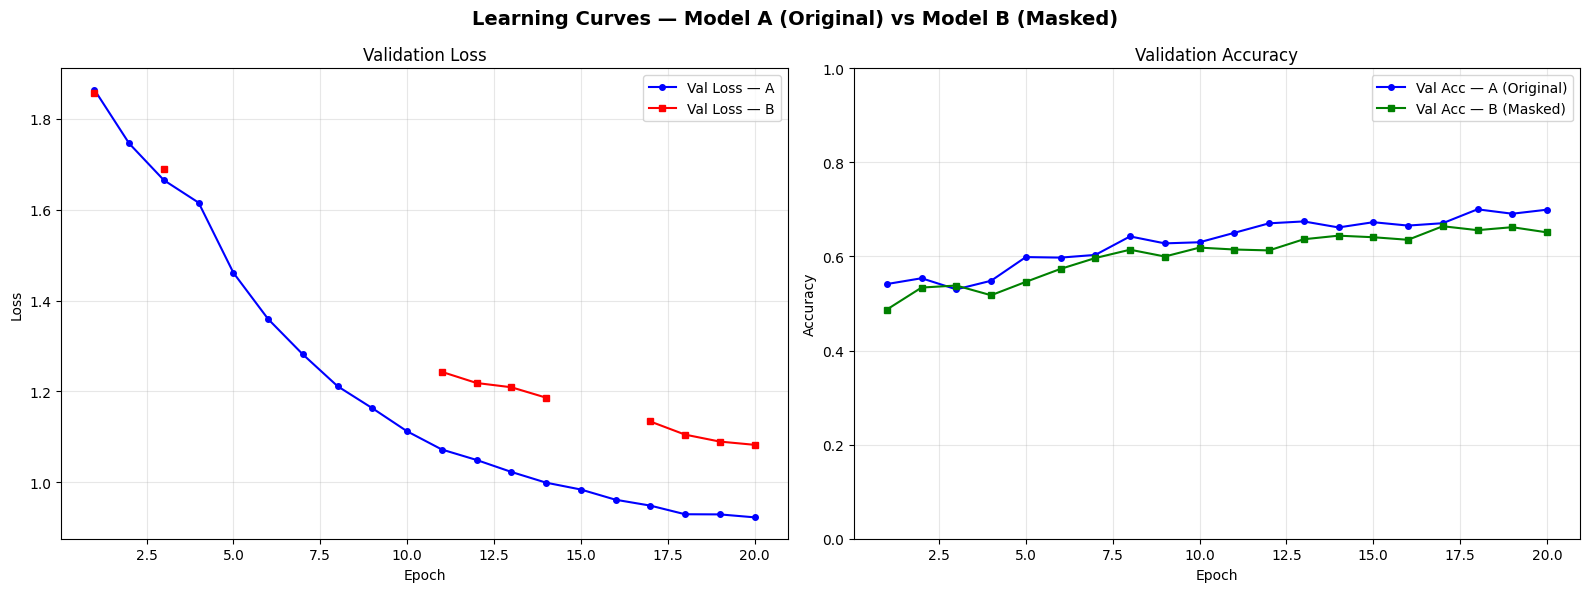

Saved: comparative_learning_curves.png


In [15]:
# ============================================================
# 11. COMPARATIVE LEARNING CURVES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Learning Curves — Model A (Original) vs Model B (Masked)",
             fontsize=14, fontweight="bold")

axes[0].plot(history_A["epoch"], history_A["val_loss"],
             "b-o", markersize=4, label="Val Loss — A")
axes[0].plot(history_B["epoch"], history_B["val_loss"],
             "r-s", markersize=4, label="Val Loss — B")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Validation Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_A["epoch"], history_A["val_acc"],
             "b-o", markersize=4, label="Val Acc — A (Original)")
axes[1].plot(history_B["epoch"], history_B["val_acc"],
             "g-s", markersize=4, label="Val Acc — B (Masked)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("comparative_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: comparative_learning_curves.png")

In [16]:
# ============================================================
# 12. FINAL EVALUATION — TEST SET
# ============================================================
def evaluate_model(model, test_loader, model_name):
    model.load_state_dict(torch.load(
        f"efficientnet_{model_name}.pth",
        map_location=device, weights_only=True))
    model.eval()

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels, _ in test_loader:
            imgs = imgs.to(device)
            with torch.amp.autocast("cuda", enabled=(device.type=="cuda")):
                out = model(imgs)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            preds = out.argmax(dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc = (all_preds == all_labels).mean()
    try:
        auc = roc_auc_score(all_labels, all_probs,
                            multi_class="ovr", average="macro")
    except Exception:
        auc = float("nan")

    print(f"\n{'='*60}")
    print(f"  MODEL {model_name} — TEST SET RESULTS")
    print(f"{'='*60}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Macro AUC : {auc:.4f}")
    print(f"\n{classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)}")

    return all_preds, all_labels, all_probs, acc, auc

preds_A, labels_A, probs_A, acc_A, auc_A = evaluate_model(
    model_A, test_loader_A, "A_original")
preds_B, labels_B, probs_B, acc_B, auc_B = evaluate_model(
    model_B, test_loader_B, "B_masked")


  MODEL A_original — TEST SET RESULTS
  Accuracy  : 0.6997
  Macro AUC : nan

              precision    recall  f1-score   support

         MEL     0.6599    0.5258    0.5852       679
          NV     0.8843    0.7996    0.8398      1931
         BCC     0.6972    0.7014    0.6993       499
          AK     0.3744    0.5615    0.4492       130
         BKL     0.4807    0.6005    0.5339       393
          DF     0.2755    0.7500    0.4030        36
        VASC     0.3855    0.8421    0.5289        38
         SCC     0.2778    0.4255    0.3361        94

    accuracy                         0.6997      3800
   macro avg     0.5044    0.6508    0.5469      3800
weighted avg     0.7347    0.6997    0.7112      3800


  MODEL B_masked — TEST SET RESULTS
  Accuracy  : 0.6608
  Macro AUC : nan

              precision    recall  f1-score   support

         MEL     0.6425    0.4315    0.5163       679
          NV     0.8469    0.8105    0.8283      1931
         BCC     0.6667    0.6

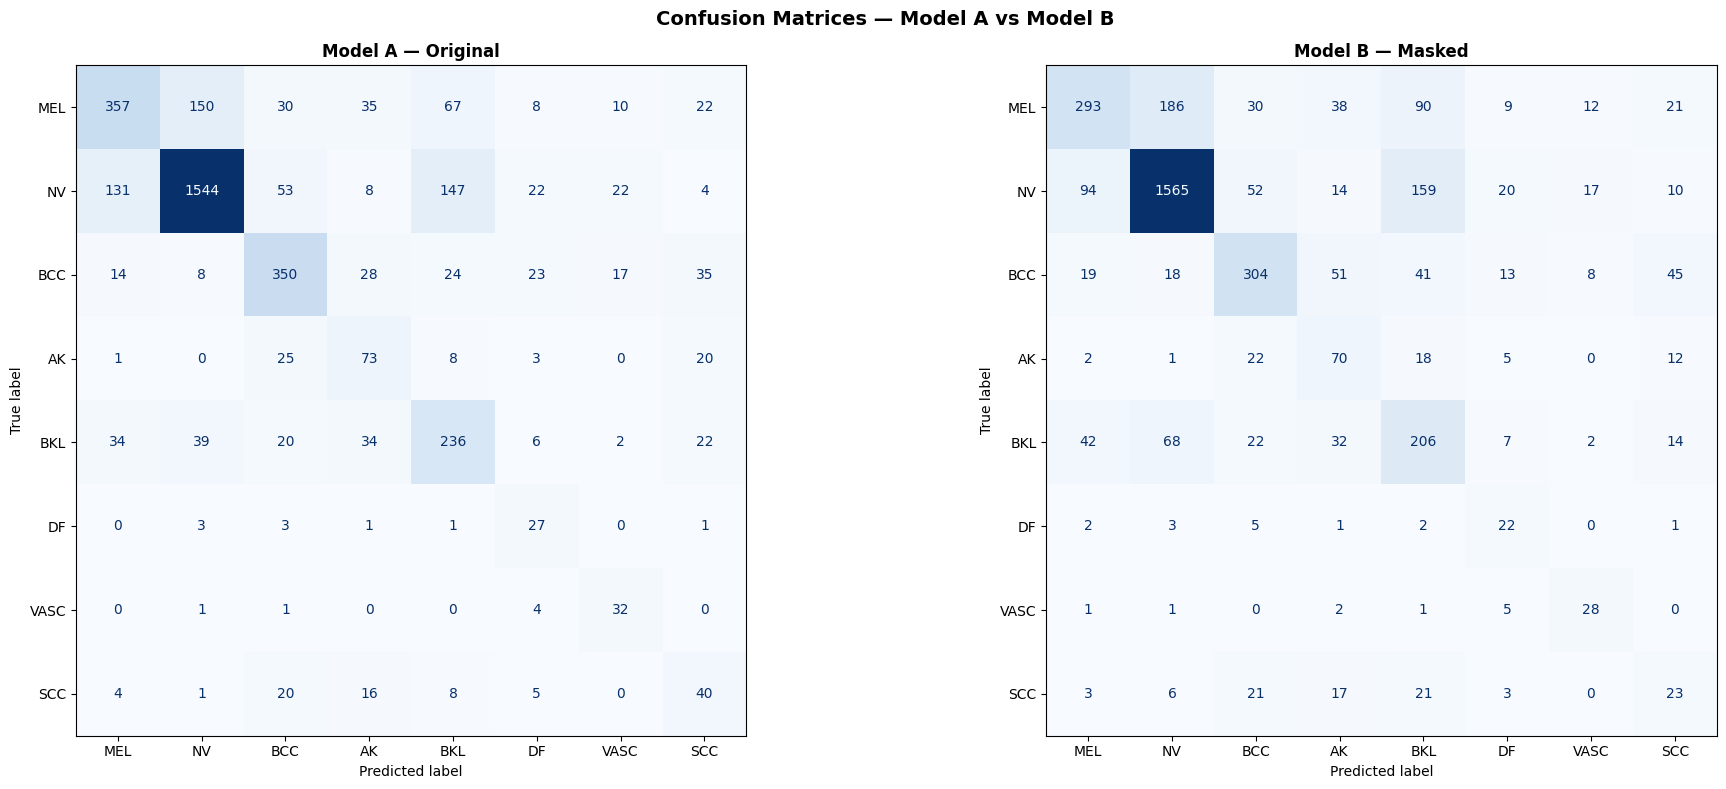

Saved: confusion_matrices.png


In [17]:
# ============================================================
# 13. CONFUSION MATRICES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Confusion Matrices — Model A vs Model B",
             fontsize=14, fontweight="bold")

for ax, preds, labels, title in zip(
    axes,
    [preds_A, preds_B],
    [labels_A, labels_B],
    ["Model A — Original", "Model B — Masked"]
):
    cm   = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

In [18]:
# ============================================================
# 14. FINAL COMPARISON TABLE
# ============================================================
f1_A = f1_score(labels_A, preds_A, average="macro")
f1_B = f1_score(labels_B, preds_B, average="macro")

print("\n" + "="*58)
print("  FINAL COMPARISON — Model A vs Model B")
print("="*58)
print(f"  {'Metric':<20} {'Model A (Original)':>18} {'Model B (Masked)':>16}")
print("-"*58)
print(f"  {'Accuracy':<20} {acc_A:>18.4f} {acc_B:>16.4f}")
print(f"  {'Macro F1':<20} {f1_A:>18.4f} {f1_B:>16.4f}")
print(f"  {'Macro AUC-ROC':<20} {auc_A:>18.4f} {auc_B:>16.4f}")
print("="*58)

winner = "A (Original)" if acc_A >= acc_B else "B (Masked)"
diff   = abs(acc_A - acc_B) * 100
print(f"\n  Best model: {winner} (+{diff:.2f}% accuracy)")

with open("comparison_results.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["metric", "model_A_original", "model_B_masked"])
    writer.writerow(["accuracy", f"{acc_A:.6f}", f"{acc_B:.6f}"])
    writer.writerow(["macro_f1", f"{f1_A:.6f}", f"{f1_B:.6f}"])
    writer.writerow(["macro_auc", f"{auc_A:.6f}", f"{auc_B:.6f}"])
print("Saved: comparison_results.csv")


  FINAL COMPARISON — Model A vs Model B
  Metric               Model A (Original) Model B (Masked)
----------------------------------------------------------
  Accuracy                         0.6997           0.6608
  Macro F1                         0.5469           0.4909
  Macro AUC-ROC                       nan              nan

  Best model: A (Original) (+3.89% accuracy)
Saved: comparison_results.csv


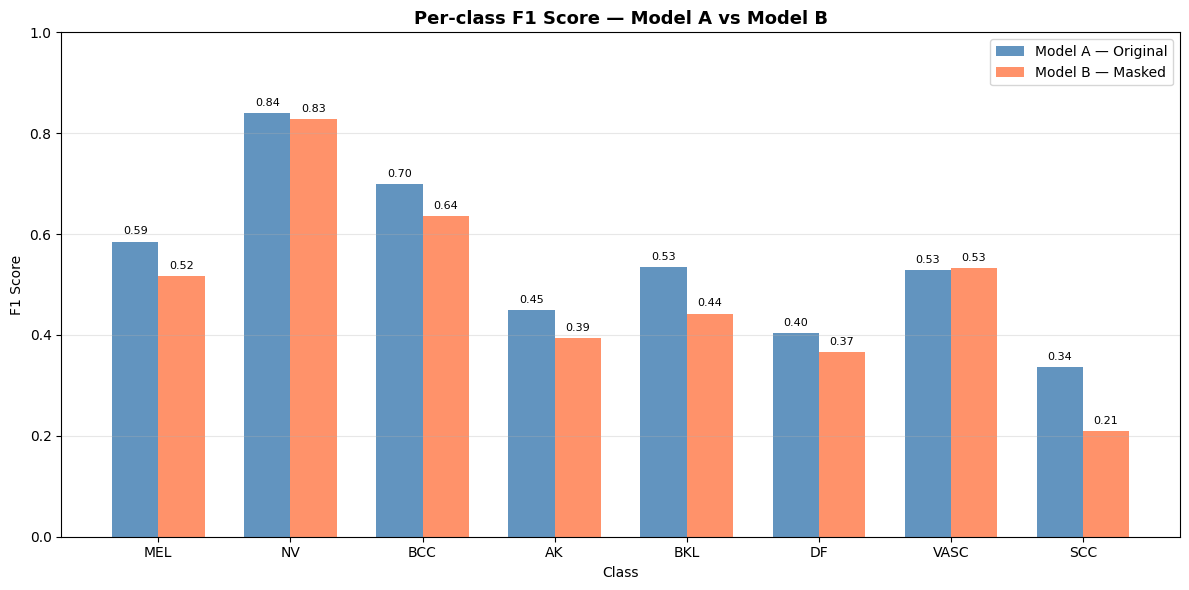

Saved: perclass_f1_comparison.png


In [19]:
# ============================================================
# 15. PER-CLASS F1 COMPARISON
# ============================================================
f1_A_per = f1_score(labels_A, preds_A, average=None)
f1_B_per = f1_score(labels_B, preds_B, average=None)

x     = np.arange(NUM_CLASSES)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars_A = ax.bar(x - width/2, f1_A_per, width,
                label="Model A — Original", color="steelblue", alpha=0.85)
bars_B = ax.bar(x + width/2, f1_B_per, width,
                label="Model B — Masked",   color="coral",     alpha=0.85)

ax.set_xlabel("Class"); ax.set_ylabel("F1 Score")
ax.set_title("Per-class F1 Score — Model A vs Model B",
             fontsize=13, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.3, axis="y")

for bar in bars_A:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
for bar in bars_B:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("perclass_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: perclass_f1_comparison.png")

In [20]:
# ============================================================
# 16. DOWNLOAD ALL RESULTS
# ============================================================
import shutil

folder = "TFG_Classification_Results"
os.makedirs(folder, exist_ok=True)

files = [
    "efficientnet_A_original.pth",
    "efficientnet_B_masked.pth",
    "history_A_original.csv",
    "history_B_masked.csv",
    "comparison_results.csv",
    "comparative_learning_curves.png",
    "confusion_matrices.png",
    "perclass_f1_comparison.png",
]

for f in files:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(folder, f))
        print(f"✅ {f}")
    else:
        print(f"⚠️  {f} no encontrado")

shutil.make_archive("TFG_Classification_Results", "zip", folder)
print("\n ZIP created: TFG_Classification_Results.zip")
print("Download it from the Jupyter file browser → right-click → Download")

✅ efficientnet_A_original.pth
✅ efficientnet_B_masked.pth
✅ history_A_original.csv
✅ history_B_masked.csv
✅ comparison_results.csv
✅ comparative_learning_curves.png
✅ confusion_matrices.png
✅ perclass_f1_comparison.png

 ZIP created: TFG_Classification_Results.zip
Download it from the Jupyter file browser → right-click → Download
